In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
BASE_DIR = '/root/workspace/vllm'
linestyle = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
markers = ['o', 's', 'D', '^', 'v', 'p', 'P', '*', 'X', 'H']

In [3]:
# Diffrerent Number of Prompts

In [4]:
def get_throughput(model_names, preemption_modes, various_num_prompts, various_request_rates, various_req_rate_models):
    gpu_utils = [0.3, 0.6]

    input_throughputs = []
    output_throughputs = []
    p99_ttfts, p99_tpots = [], []
    for model_name in model_names:
        input_token_throughputs = []
        output_token_throughputs = []
        p99_ttft = []
        p99_tpot = []
        gpu_util = gpu_utils[model_names.index(model_name)]
        if various_num_prompts:
            num_prompts = [100*i for i in range(1, 11)]
            request_rate = 10
            directory = f'{BASE_DIR}/examples/logs/1_colorun_llm_1gpu/colo_swap_recompute'
            for num_prompt in num_prompts:
                file_path = f'{directory}/{model_names[0]}-{model_names[1]}/{model_name}_client_{gpu_util}_{request_rate}_{num_prompt}_{preemption_modes[0]}_{preemption_modes[1]}.log'
                with open(file_path, 'r') as file:
                    lines = file.readlines()
                    for line in lines:
                        if 'Input token throughput' in line:
                            input_throughput = float(line.split()[-1])
                            input_token_throughputs.append(input_throughput)
                        elif 'Output token throughput' in line:
                            output_throughput = float(line.split()[-1])
                            output_token_throughputs.append(output_throughput)
                        elif "P99 TTFT" in line:
                            p99_ttft.append(float(line.split()[-1]))
                        elif "P99 TPOT" in line:
                            p99_tpot.append(float(line.split()[-1])) 
        if various_request_rates:
            request_rates = [5*i for i in range(1, 11)]
            num_prompt = 100
            directory = f'{BASE_DIR}/examples/logs/1_colorun_llm_1gpu/colo_swap_recompute_varied_request_rate'
            for request_rate in request_rates:
                file_path = f'{directory}/{model_names[0]}-{model_names[1]}/{model_name}_client_{gpu_util}_{request_rate}_{num_prompt}_{preemption_modes[0]}_{preemption_modes[1]}.log'
                # print(file_path)
                with open(file_path, 'r') as file:
                    lines = file.readlines()
                    for line in lines:
                        if 'Input token throughput' in line:
                            input_throughput = float(line.split()[-1])
                            input_token_throughputs.append(input_throughput)
                        elif 'Output token throughput' in line:
                            output_throughput = float(line.split()[-1])
                            output_token_throughputs.append(output_throughput)
                        elif "P99 TTFT" in line:
                            p99_ttft.append(float(line.split()[-1]))
                        elif "P99 TPOT" in line:
                            p99_tpot.append(float(line.split()[-1]))                       
        if various_req_rate_models:
            num_prompt = 100
            directory = f'{BASE_DIR}/examples/logs/1_colorun_llm_1gpu/colo_swap_recompute_various_req_rate_models'
            if model_name == model_names[0]: 
                request_rates = [5*i for i in range(1, 11)]
            else:
                request_rates = [55-5*i for i in range(1, 11)]
            for request_rate in request_rates:
                file_path = f'{directory}/{model_names[0]}-{model_names[1]}/{model_name}_client_{gpu_util}_{request_rate}_{num_prompt}_{preemption_modes[0]}_{preemption_modes[1]}.log'
                # print(file_path)
                with open(file_path, 'r') as file:
                    lines = file.readlines()
                    for line in lines:
                        if 'Input token throughput' in line:
                            input_throughput = float(line.split()[-1])
                            input_token_throughputs.append(input_throughput)
                        elif 'Output token throughput' in line:
                            output_throughput = float(line.split()[-1])
                            output_token_throughputs.append(output_throughput)
                        elif "P99 TTFT" in line:
                            p99_ttft.append(float(line.split()[-1]))
                        elif "P99 TPOT" in line:
                            p99_tpot.append(float(line.split()[-1]))


        # print(f"Model: {model_name}, preemption_modes: {preemption_modes}")
        # print("Input token throughputs:", input_token_throughputs)
        # print("Output token throughputs:", output_token_throughputs)
        input_throughputs.append(input_token_throughputs)
        output_throughputs.append(output_token_throughputs)
        p99_ttfts.append(p99_ttft)
        p99_tpots.append(p99_tpot)

    return input_throughputs, output_throughputs, p99_ttfts, p99_tpots    

In [16]:
def plt_throughput(model_names, metric_type, varioud_num_prompts, various_request_rates, various_req_rate_models):
    
    fig = plt.figure(figsize=(3, 2), dpi=120, facecolor='w', edgecolor='k')
    ax = fig.add_subplot(111)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    if varioud_num_prompts: x_labels = [100*i for i in range(1, 11)]
    if various_request_rates: x_labels = [5*i for i in range(1, 11)] 
    else: x_labels = [5*i for i in range(1, 11)]   
    preemption_modes = [['swap', 'recompute'], ['recompute', 'swap'], ['swap', 'swap'], ['recompute', 'recompute']]
    labels = ['S-R', 'R-S', 'S-S', 'R-R']

    improvements = []

    for i in range(len(preemption_modes)):
        preemption_mode = preemption_modes[i]
        input_throughputs, output_throughputs, ttft_latency, tpot_latency = get_throughput(model_names, preemption_mode, varioud_num_prompts, various_request_rates, various_req_rate_models)
        # print(f"Preemption Mode: {preemption_mode}")
        # print(f'input_throughputs: {input_throughputs}, output_throughputs: {output_throughputs}, ttft: {ttft_latency}, tpot: {tpot_latency}')
        sum_input = np.sum(input_throughputs, axis=0)
        sum_output = np.sum(output_throughputs, axis=0)
        improvement = (np.max(sum_output) - np.min(sum_output)) / np.min(sum_output)
        improvements.append(improvement)
        ttft_latency = np.mean(ttft_latency, axis=0)
        tpot_latency = np.mean(tpot_latency, axis=0)

        if metric_type == 'sum_input':
            ax.plot(x_labels, sum_input, label=labels[i], marker=markers[i], linestyle=linestyle[i], markersize=3, color=plt.cm.Dark2(i))
        elif metric_type == 'sum_output':    
            ax.plot(x_labels, sum_output, label=labels[i], marker=markers[i], linestyle=linestyle[i], markersize=3, color=plt.cm.Dark2(i))
        elif metric_type == 'ttft':
            ax.plot(x_labels, ttft_latency, label=labels[i], marker=markers[i], linestyle=linestyle[i], markersize=3, color=plt.cm.Dark2(i))
        elif metric_type == 'tpot':
            ax.plot(x_labels, tpot_latency, label=labels[i], marker=markers[i], linestyle=linestyle[i], markersize=3, color=plt.cm.Dark2(i))  
        
    if varioud_num_prompts: ax.set_xlabel('Number of prompts')
    if various_request_rates or various_req_rate_models: ax.set_xlabel('Request rate (req/s)')    
    if metric_type == 'sum_input': ax.set_ylabel('Input Throughput (tok/s)')
    elif metric_type == 'sum_output': ax.set_ylabel('Output Throughput (tok/s)')
    elif metric_type == 'ttft': ax.set_ylabel('TTFT (ms)')
    elif metric_type == 'tpot': ax.set_ylabel('TPOT (ms)')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(loc='best', ncol=2, handlelength=1.6, handletextpad=0.5, columnspacing=0.6, frameon=False) 
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=.0)
    plt.show()

    # print the max improvement of output throughput
    print(f"Model: {model_names}, Max improvement of output throughput: {np.max(improvements)}")

# plt_throughput('sum_output', True, False, False)
# plt_throughput('ttft', True, False, False)
# plt_throughput('tpot', True, False, False)

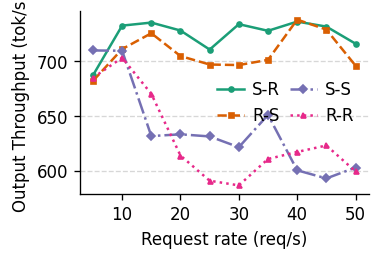

Model: ['opt-6.7b', 'Llama-2-13b-hf'], Max improvement of output throughput: 0.19901812045071


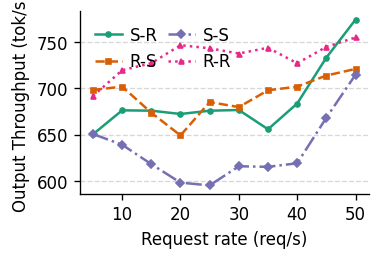

Model: ['opt-6.7b', 'Llama-2-13b-hf'], Max improvement of output throughput: 0.20099447328193


In [17]:
model_names = ['opt-6.7b', 'Llama-2-13b-hf']
plt_throughput(model_names, 'sum_output', False, True, False)
# plt_throughput(model_names, 'ttft', False, True, False)
# plt_throughput(model_names, 'tpot', False, True, False)
plt_throughput(model_names, 'sum_output', False, False, True)

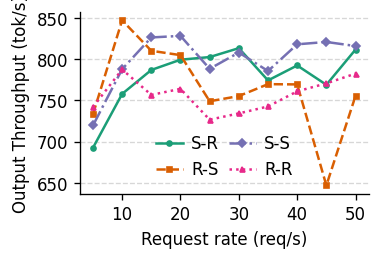

Model: ['opt-2.7b', 'opt-13b'], Max improvement of output throughput: 0.31031123892573875


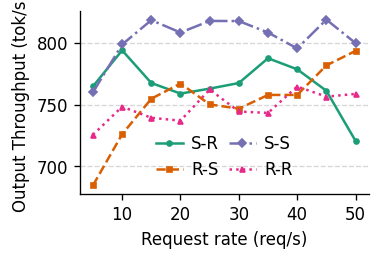

Model: ['opt-2.7b', 'opt-13b'], Max improvement of output throughput: 0.15898102569346056


In [18]:
model_names = ['opt-2.7b', 'opt-13b']
plt_throughput(model_names, 'sum_output', False, True, False)
plt_throughput(model_names, 'sum_output', False, False, True)
# plt_throughput(model_names, 'ttft', False, True, False)
# plt_throughput(model_names, 'tpot', False, True, False)
# plt_throughput(model_names, 'sum_output', False, False, True)